In [1]:
import joblib as joblib
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, balanced_accuracy_score, classification_report, confusion_matrix

In [2]:
x = Path('/Users/arthur/Library/Mobile Documents/com~apple~CloudDocs/Documents/Marseille/aMU/M1/Stage/2026_09_28_lowess_trainingset_2.csv')
df = pd.read_csv(x)
df = df.rename(columns={'RDX_area_min': 'RD_area_min', 'RDX_area_max': 'RD_area_max'})

id = df.loc[:, 'id']
X = df.drop(columns=['id', 'condition'])
y = df.loc[:, 'condition']

### Use more features

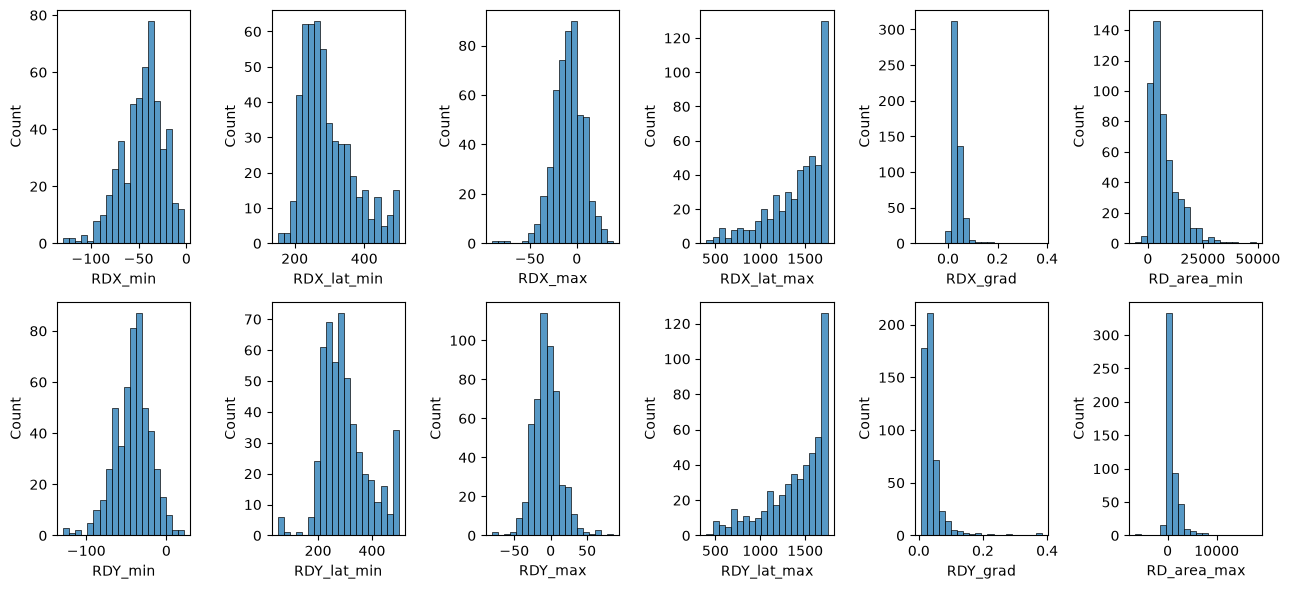

In [ ]:
fig, ax = plt.subplots(2, 6, figsize=(13, 6))

sns.histplot(df, x='RDX_min', bins=20, ax=ax[0][0])
sns.histplot(df, x='RDY_min', bins=20, ax=ax[1][0])

sns.histplot(df, x='RDX_lat_min', bins=20, ax=ax[0][1])
sns.histplot(df, x='RDY_lat_min', bins=20, ax=ax[1][1])

sns.histplot(df, x='RDX_max', bins=20, ax=ax[0][2])
sns.histplot(df, x='RDY_max', bins=20, ax=ax[1][2])

sns.histplot(df, x='RDX_lat_max', bins=20, ax=ax[0][3])
sns.histplot(df, x='RDY_lat_max', bins=20, ax=ax[1][3])

sns.histplot(df, x='RDX_grad', bins=20, ax=ax[0][4])
sns.histplot(df, x='RDY_grad', bins=20, ax=ax[1][4])

sns.histplot(df, x='RD_area_min', bins=20, ax=ax[0][5])
sns.histplot(df, x='RD_area_max', bins=20, ax=ax[1][5])

# sns.histplot(df, x='RDX_area_max', bins=30, ax=ax[6][0])
# sns.histplot(df, x='RDX_area_max', bins=30, ax=ax[6][1])

# ax[0][0].set_title('RDX')
# ax[0][1].set_title('RDY')


plt.tight_layout()
# plt.savefig('figures/analysis/increased_features_histogram.png', dpi=450)

### Train model on new data

In [3]:
model = joblib.load('models/logistic_regression.pkl')

In [12]:
numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad', 'RDY_min', 'RDY_lat_min', 'RDY_lat_max', 'RDY_max', 'RDY_grad', 'RD_area_min', 'RD_area_max']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
# numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=200, subsample=200, output_distribution="normal", copy=True, random_state=42))])

categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)), 
    ('clf', clone(model['best_model']['clf']))
])


results = {
    'accuracy': [],
    'proba': [],
    'f1_score': [],
    'balanced_accuracy': [],
    'classification_report': [],
    'train_cond_distribution': [],
    'test_cond_distribution': [],
    'confusion_matrices': [],
    'best_model': [],
    'train_idx_folds': [],
    'X_train_folds': [],
    'y_train_folds': []
}

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in gss.split(X, groups=id):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    lr = pipeline.fit(X_train, y_train)

    y_pred = lr.predict(X_test)
    score = lr.score(X_test, y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    y_pred = lr.predict(X_test)
    results['accuracy'].append(score)
    results['f1_score'].append(f1_macro)
    results['balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred, adjusted=True))
    results['classification_report'].append(classification_report(y_test, y_pred))
    results['train_idx_folds'].append(train_idx)
    results['X_train_folds'].append(X_train)
    results['y_train_folds'].append(y_train)
    results['best_model'].append(lr)

    results['train_cond_distribution'].append(y_train.value_counts()/6)
    results['test_cond_distribution'].append(y_test.value_counts()/6)

    cm = confusion_matrix(y_test, y_pred)
    results['confusion_matrices'].append(cm)

In [16]:
print(results['balanced_accuracy'])
results['f1_score']

[0.060185185185185196]


[0.25980515373304747]

### More complex model?

In [49]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, classification_report


## Scaling
numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad', 'RDY_min', 'RDY_lat_min', 'RDY_lat_max', 'RDY_max', 'RDY_grad', 'RD_area_min', 'RD_area_max']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
# numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=200, subsample=200, output_distribution="normal", copy=True, random_state=42))])

categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)), 
    ('clf', SVC(random_state=42))
])

# pipeline = Pipeline(
#     [
#         ("preprocessor", preprocessor),
#         ('clf', SVC(random_state=42))
# ])

param_grid = [
    {
        'clf' : [SVC(random_state=42)],
        'clf__C': [0.01, 0.1, 1, 10, 100],
        'clf__gamma': ['scale', 'auto', 0.0001, 0.001, 0.01],
        'clf__kernel': ['linear', 'rbf', 'poly'],
        'clf__degree': [2, 3, 4]

    },
    {
        'clf' : [RandomForestClassifier(random_state=42)],
        'clf__n_estimators': [1, 10, 50, 100],
        'clf__criterion': ['gini', 'entropy', 'log_loss'],
        'clf__max_depth': [5, 20, 50, 100],
        'clf__min_samples_split': [2, 5, 8, 10]
    },
    {
        'clf' : [LogisticRegression(random_state=42)],
        'clf__C': [0.01, 0.1, 0.5, 1.0, 1.5, np.inf],
        'clf__l1_ratio': [0, 0.5, 1],
        'clf__solver': ['lbfgs', 'newton-cholesky', 'sag', 'saga'],
        'clf__max_iter': [50, 200, 500, 1000]
    },
    {
        'clf' : [GradientBoostingClassifier(random_state=42)],
        'clf__loss': ['log_loss'],
        'clf__learning_rate': [0.01, 0.1, 1],
        'clf__n_estimators': [1, 100, 1000],
        'clf__min_samples_split': [2, 4, 6],
        'clf__max_depth': [1, 3, 5]
    },
    {
        'clf' : [KNeighborsClassifier()],
        'clf__n_neighbors': [1, 2, 3, 5],
        'clf__weights': ['uniform', 'distance'],
        'clf__algorithm': ['ball_tree', 'kd_tree', 'brute'],
        'clf__p': [1, 2]
    },
    {
        'clf' : [AdaBoostClassifier(random_state=42)],
        'clf__n_estimators': [20, 50, 100],
        'clf__learning_rate': [0.01, 0.1, 1]
    }
]

## Store variables
results = {
    'accuracy': [],
    'proba': [],
    'f1_score': [],
    'balanced_accuracy': [],
    'classification_report': [],
    'best_params': [],
    'best_model': [],
    'train_cond_distribution': [],
    'test_cond_distribution': [],
    'confusion_matrices': [],
    'train_idx_folds': [],
    'X_train_folds': [],
    'y_train_folds': []
}

## Optimise model using GridSearchCV
outer_cv = StratifiedGroupKFold(n_splits=5)
inner_cv = StratifiedGroupKFold(n_splits=5)

for train_idx, test_idx in outer_cv.split(X, y, groups=id):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    id_train, id_test = id.iloc[train_idx], id.iloc[test_idx]

    gridsearch = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=inner_cv, n_jobs=-1)
    gridsearch.fit(X_train, y_train, groups=id_train)

    best_params = gridsearch.best_params_
    best_model = gridsearch.best_estimator_

    y_pred = best_model.predict(X_test)
    # proba = best_model.predict_proba(X_test)

    score = best_model.score(X_test, y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results['accuracy'].append(score)
    # results['proba'].append(proba)
    results['f1_score'].append(f1_macro)
    results['balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred, adjusted=True))
    results['classification_report'].append(classification_report(y_test, y_pred))

    results['best_params'].append(best_params)
    results['best_model'].append(best_model)
    results['train_idx_folds'].append(train_idx)
    results['X_train_folds'].append(X_train)
    results['y_train_folds'].append(y_train)

    results['train_cond_distribution'].append(y_train.value_counts()/6)
    results['test_cond_distribution'].append(y_test.value_counts()/6)

    cm = confusion_matrix(y_test, y_pred)
    results['confusion_matrices'].append(cm)


/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

In [50]:
print(results['f1_score'])
results['best_params']

[0.21022197312519894, 0.2765628860884606, 0.3305788775961114, 0.23823828311812528, 0.26768252755647715]


[{'clf': AdaBoostClassifier(random_state=42),
  'clf__learning_rate': 1,
  'clf__n_estimators': 50},
 {'clf': RandomForestClassifier(random_state=42),
  'clf__criterion': 'entropy',
  'clf__max_depth': 20,
  'clf__min_samples_split': 8,
  'clf__n_estimators': 100},
 {'clf': KNeighborsClassifier(),
  'clf__algorithm': 'ball_tree',
  'clf__n_neighbors': 1,
  'clf__p': 2,
  'clf__weights': 'uniform'},
 {'clf': GradientBoostingClassifier(random_state=42),
  'clf__learning_rate': 1,
  'clf__loss': 'log_loss',
  'clf__max_depth': 1,
  'clf__min_samples_split': 2,
  'clf__n_estimators': 100},
 {'clf': KNeighborsClassifier(),
  'clf__algorithm': 'ball_tree',
  'clf__n_neighbors': 5,
  'clf__p': 1,
  'clf__weights': 'distance'}]

In [47]:
print(results['classification_report'][2])

              precision    recall  f1-score   support

         ACP       0.21      0.22      0.22        18
         AMN       0.54      0.23      0.33        30
         CTR       0.33      0.58      0.42        24
         DFT       0.32      0.30      0.31        30

    accuracy                           0.33       102
   macro avg       0.35      0.33      0.32       102
weighted avg       0.37      0.33      0.33       102



### Ablation study

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import QuantileTransformer, RobustScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

columns=X.columns

numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad', 'RDY_min', 'RDY_lat_min', 'RDY_lat_max', 'RDY_max', 'RDY_grad', 'RD_area_min', 'RD_area_max']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
categorical_transformer = Pipeline([('passthrough', 'passthrough')])

cv = StratifiedGroupKFold(5)
lr_score=[]

# Now ablation works correctly
for col in X.columns:
    df = X.copy()
    df = df.drop(columns=col)

    num = numeric_features.copy()
    cat = categorical_features.copy()

    if col in num:
        num.remove(col)

    if col in cat:
        cat.remove(col)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num),
            ('cat', categorical_transformer, cat)
        ],
        remainder='passthrough', verbose_feature_names_out=False
    )

    pipeline = Pipeline([
        ('preprocessing', preprocessor),
        ('lr', model['best_model']['clf'])
    ])

    score = cross_val_score(pipeline, df, y, cv=cv, scoring="f1_macro", groups=id)
    lr_score.append(np.mean(score))

### compute baseline ###
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('lr', model['best_model']['clf'])
])

score = np.mean(cross_val_score(pipeline, X, y, cv=cv, scoring="f1_macro", groups=id))
lr_score.append(score)

lr_score = [x - score for x in lr_score]

lr_score_desc = dict(zip(columns, lr_score))
sorted_lr = dict(sorted(lr_score_desc.items(), key=lambda x: x[1], reverse=False))

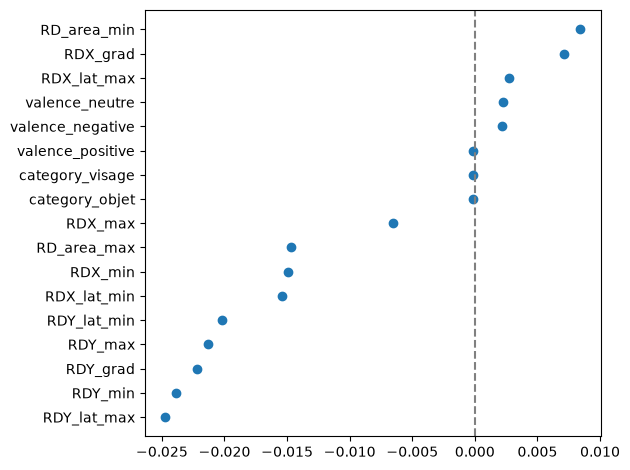

In [44]:

# plt.spines['top'].set_visible(False)
# plt.spines['right'].set_visible(False)

plt.scatter(sorted_lr.values(), sorted_lr.keys())
plt.axvline(0, c='grey', ls='--')


# for a in ax:
#     for label in a.get_yticklabels():
#         if label.get_text() == 'baseline':
#             label.set_color('red')

plt.tight_layout()
plt.savefig('figures/analysis/ablation.png', dpi=150)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, QuantileTransformer
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.base import clone
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, classification_report


## Scaling
numeric_features = ['RDX_min', 'RDX_lat_min', 'RDX_lat_max', 'RDX_max', 'RDX_grad', 'RDY_min', 'RDY_lat_min', 'RDY_lat_max', 'RDY_max', 'RDY_grad', 'RD_area_min', 'RD_area_max']
categorical_features = ['category_objet', 'category_visage', 'valence_negative', 'valence_neutre', 'valence_positive']

numeric_transformer = Pipeline([('scaler', RobustScaler())])
# numeric_transformer = Pipeline([('scaler', QuantileTransformer(n_quantiles=200, subsample=200, output_distribution="normal", copy=True, random_state=42))])

categorical_transformer = Pipeline([('passthrough', 'passthrough')])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough', verbose_feature_names_out=False
)

pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)), 
    ('clf', SVC(random_state=42))
])

best_config = grid.best_estimator_      # fitted on the old data
model = clone(model['best_model']['clf'])              # same hyperparameters, no learned weights
model.fit(X_new, y_new)                 # train from scratch on the new data

for train_idx, test_idx in outer_cv.split(X, y, groups=id):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    id_train, id_test = id.iloc[train_idx], id.iloc[test_idx]

    gridsearch = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1_macro', cv=inner_cv, n_jobs=-1)
    gridsearch.fit(X_train, y_train, groups=id_train)

    best_params = gridsearch.best_params_
    best_model = gridsearch.best_estimator_

    y_pred = best_model.predict(X_test)
    # proba = best_model.predict_proba(X_test)

    score = best_model.score(X_test, y_test)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results['accuracy'].append(score)
    # results['proba'].append(proba)
    results['f1_score'].append(f1_macro)
    results['balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred, adjusted=True))
    results['classification_report'].append(classification_report(y_test, y_pred))

    results['best_params'].append(best_params)
    results['best_model'].append(best_model)
    results['train_idx_folds'].append(train_idx)
    results['X_train_folds'].append(X_train)
    results['y_train_folds'].append(y_train)

    results['train_cond_distribution'].append(y_train.value_counts()/6)
    results['test_cond_distribution'].append(y_test.value_counts()/6)

    cm = confusion_matrix(y_test, y_pred)
    results['confusion_matrices'].append(cm)


In [14]:
results['best_model'][0]

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](4,)","['ACP','AMN','CTR','DFT']"
feature_names_in_,"ndarray[object](17,)","['RDX_min','RDX_lat_min','RDX_max',...,'valence_negative','valence_neutre', 'valence_positive']"
n_features_in_,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False


In [47]:
results

{'accuracy': [0.26851851851851855],
 'proba': [],
 'f1_score': [0.25980515373304747],
 'balanced_accuracy': [0.060185185185185196],
 'classification_report': ['              precision    recall  f1-score   support\n\n         ACP       0.41      0.46      0.43        24\n         AMN       0.18      0.44      0.26        18\n         CTR       0.13      0.11      0.12        18\n         DFT       0.36      0.17      0.23        48\n\n    accuracy                           0.27       108\n   macro avg       0.27      0.30      0.26       108\nweighted avg       0.30      0.27      0.26       108\n'],
 'train_cond_distribution': [condition
  AMN    24.0
  CTR    17.0
  DFT    16.0
  ACP    11.0
  Name: count, dtype: float64],
 'test_cond_distribution': [condition
  DFT    8.0
  ACP    4.0
  AMN    3.0
  CTR    3.0
  Name: count, dtype: float64],
 'confusion_matrices': [array([[11,  7,  3,  3],
         [ 3,  8,  1,  6],
         [ 4,  7,  2,  5],
         [ 9, 22,  9,  8]])],
 'train_id

In [9]:
model['best_model'][1]

SMOTE(random_state=42)

/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
3 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/model_selection/_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arthur/git/2026_M1_internship/.venv/lib/python3.14/site-packages/sklearn/base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/arthur/git/2026_M1_

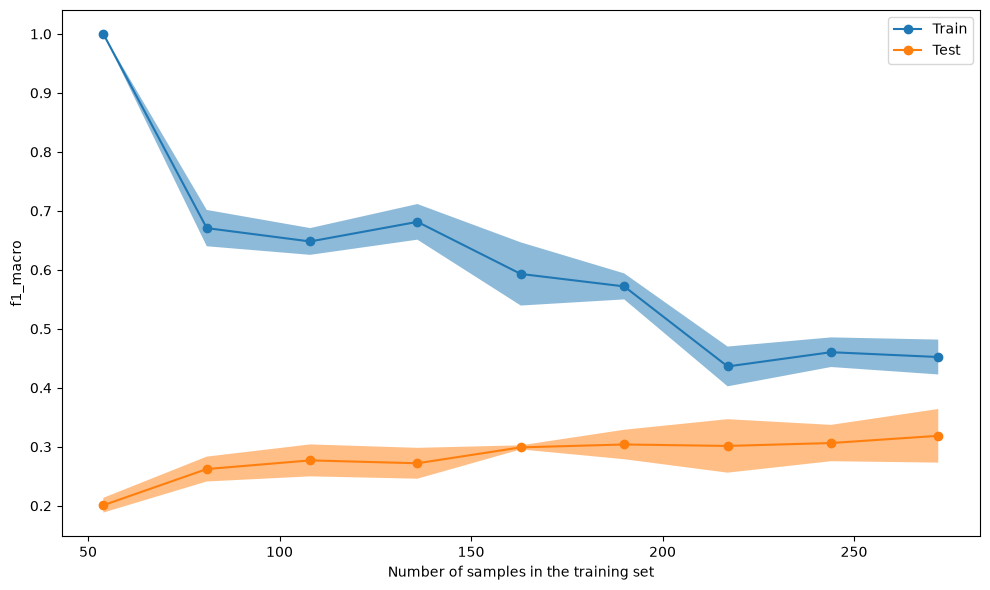

In [15]:
from sklearn.model_selection import learning_curve, StratifiedKFold, LearningCurveDisplay

fig, ax = plt.subplots(1, figsize=(10, 6))

train_sizes = np.linspace(0.1, 1.0, 10)
cv_for_learning = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

X_train = results['X_train_folds'][0]
y_train = results['y_train_folds'][0]
estimator = results['best_model'][0]

common_params = {
    "X": X_train,
    "y": y_train,
    "train_sizes": train_sizes,
    "cv": cv_for_learning,
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "f1_macro",
}

LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax)
# handles, label = ax[ax_idx].get_legend_handles_labels()
# ax[ax_idx].legend(handles[:2], ["Training Score", "Test Score"])
# ax[ax_idx].set_title(f"Learning Curve for {results['best_params'][ax_idx]['clf']}")


plt.tight_layout()
plt.savefig('figures/dataset3_balanced_learningcurve.png', dpi=150)

In [6]:
results

{'accuracy': [0.26851851851851855],
 'proba': [],
 'f1_score': [0.25980515373304747],
 'balanced_accuracy': [0.060185185185185196],
 'classification_report': ['              precision    recall  f1-score   support\n\n         ACP       0.41      0.46      0.43        24\n         AMN       0.18      0.44      0.26        18\n         CTR       0.13      0.11      0.12        18\n         DFT       0.36      0.17      0.23        48\n\n    accuracy                           0.27       108\n   macro avg       0.27      0.30      0.26       108\nweighted avg       0.30      0.27      0.26       108\n'],
 'train_cond_distribution': [condition
  AMN    24.0
  CTR    17.0
  DFT    16.0
  ACP    11.0
  Name: count, dtype: float64],
 'test_cond_distribution': [condition
  DFT    8.0
  ACP    4.0
  AMN    3.0
  CTR    3.0
  Name: count, dtype: float64],
 'confusion_matrices': [array([[11,  7,  3,  3],
         [ 3,  8,  1,  6],
         [ 4,  7,  2,  5],
         [ 9, 22,  9,  8]])],
 'train_id